# LEZIONE 05 - DFS IN GRAFI DIRETTI

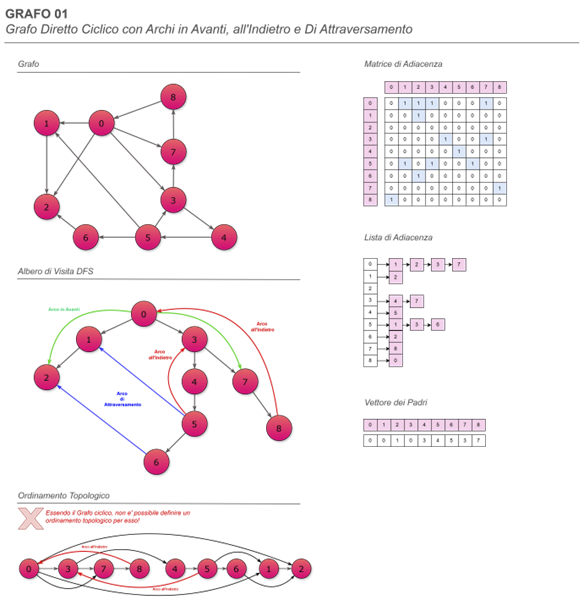

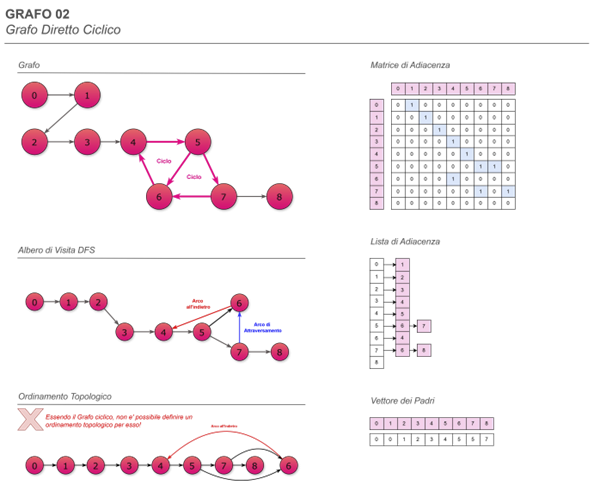

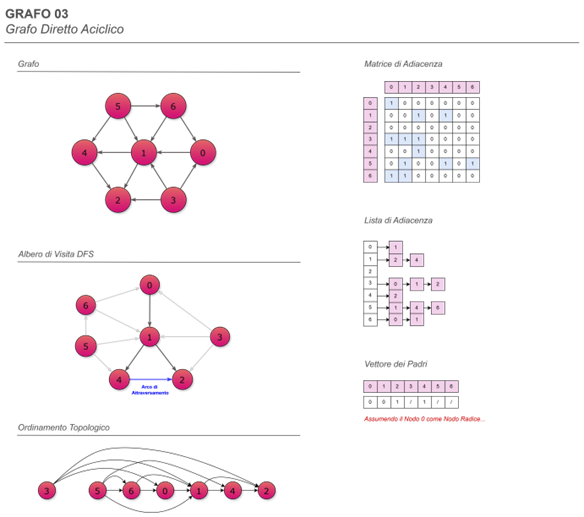

## Codice Python

In [1]:
import numpy as np

In [1]:
# -*- coding: utf-8 -*-
"""
LEZIONE 05 - DFS IN GRAFI DIRETTI

Algoritmi di utilita' tramite uso di DFS
    - Ricerca Archi in Grafi Diretti
        - archi in avanti, archi all'indietro, archi di attraversamento
    - Ricerca Ciclo a partire da un Nodo Specifico in Grafi Diretti
        - True non appena trova un Ciclo
    - Ricerca Ciclo in Grafi diretti
        - True non appena trova un Ciclo 
    - Ordinamento Topologico
        - in Grafi Diretti Aciclici (DAG)
        
"""


" ALGORITMI *****************************************************************"



class GrafoDiretto:
    
    visitati=[]                     # Vettore dei Nodi Visitati        
    T=[]                            # Vettore dei Tempi di Visita
    L=[]                            # Vettore dei Nodi in Ordine Topologico
    archi_albero=0                  # Contatore Archi dell'albero DFS
    archi_avanti=0                  # Contatore Archi in Avanti
    archi_indietro=0                # Contatore Archi all'Indietro
    archi_attraversamento=0         # Contatore Archi di Attraversamento
    listaAdiacenza=[]               # Lista di Adiacenza
    padri=[]                        # Vettore dei Padri
    c=0                             # Contatore Tempo di Visita
    
    
    def __init__(self,listaAdiacenza):
        self.listaAdiacenza=listaAdiacenza
    
    
    # RICERCA degli ARCHI [Grafi Diretti]

    def __DFS_Archi(self,u):                                      # S(n,m)
        self.visitati[u]=1                                        # Θ(1)
        self.c+=1                                                 # Θ(1)
        self.T[u]=self.c                                          # Θ(1)
        for v in self.listaAdiacenza[u]:                          # k*Θ(1)+Θ(1)
            if self.visitati[v]==0:                               # Θ(1)
                self.archi_albero+=1                              # Θ(1)
                self.padri[v]=u                                   # Θ(1)
                self.__DFS_Archi(v)                               # S(n-1,v)      
            else:                                                 # Θ(1)
                if self.T[u]<self.T[v]:                           # Θ(1)
                    self.archi_avanti+=1                          # Θ(1)
                else:                                             # Θ(1)
                    if self.visitati[v]==1:                       # Θ(1)
                        self.archi_indietro+=1                    # Θ(1)
                    else:                                         # Θ(1)
                        self.archi_attraversamento+=1             # Θ(1)
        self.visitati[u]=2                                        # Θ(1)


    def ricercaArchi(self,s):                                     # T(n,m)
    
        self.visitati=[0 for v in self.listaAdiacenza]            # Θ(n)
        self.T=[0 for v in self.listaAdiacenza]                   # Θ(n)
        self.c=0                                                  # Θ(1)
        self.padri=[-1 for v in self.listaAdiacenza]              # Θ(n)
        self.padri[s]=s                                           # Θ(1)

        self.__DFS_Archi(s)                                       # S(n,m)
        
        return [self.archi_albero, self.archi_avanti, 
                self.archi_indietro, self.archi_attraversamento]  # Θ(1)
       
    # Costo Computazionale: Θ(n+m)   - CASO PEGGIORE/MIGLIORE   



    # RICERCA Ciclo a partire da un Nodo Specifico [Grafi Diretti]

    def __DFS_Ciclo(self,u):                                      # S(n,m)
        self.visitati[u]=1                                        # Θ(1)
        self.c+=1                                                 # Θ(1)
        self.T[u]=self.c                                          # Θ(1)
        for v in self.listaAdiacenza[u]:                          # k*Θ(1)+Θ(1)
            if self.visitati[v]==0:                               # Θ(1)
                x=self.__DFS_Ciclo(v)                             # S(n-1,v)  
                if (x==True):                                     # Θ(1)
                    return True                                   # Θ(1)
            else:                                                 # Θ(1)
                if (self.T[u]>self.T[v] and self.visitati[v]==1): # Θ(1)
                    return True                                   # Θ(1)
        self.visitati[u]=2                                        # Θ(1)
        return False                                              # Θ(1)


    def ricercaCicloLocale(self,s):                               # T(n,m)
        self.visitati=[0 for v in self.listaAdiacenza]            # Θ(n)
        self.T=[0 for v in self.listaAdiacenza]                   # Θ(n)
        self.c=0                                                  # Θ(1)
        return self.__DFS_Ciclo(s)                                # S(n,m)
    
    # Costo Computazionale: Θ(n+m)   - CASO PEGGIORE
    #                       Ω(1)     - CASO MIGLIORE



    # RICERCA Ciclo [Grafi Diretti]
       
    def ricercaCicloGlobale(self,s):                              # T(n,m)   
        self.visitati=[0 for v in self.listaAdiacenza]            # Θ(n)
        self.T=[0 for v in self.listaAdiacenza]                   # Θ(n)
        self.c=0                                                  # Θ(1)
        ciclo=False                                               # Θ(1)
        i=0                                                       # Θ(1) 
        while ciclo==False and i<len(self.listaAdiacenza):        # n*Θ(1)+Θ(1)  
            if self.visitati[i]==0:                               # Θ(1)
                ciclo=self.__DFS_Ciclo(i)                         # S(n-1,v) 
            i+=1                                                  # Θ(1)
        return ciclo                                              # Θ(1)
    
    # Costo Computazionale: Θ(n+m)   - CASO PEGGIORE
    #                       Ω(1)     - CASO MIGLIORE



    # ORDINAMENTO TOPOLOGICO [Grafi Diretti]
    
    def __DFS_Topologico(self,u):                                 # S(n,m)
        self.visitati[u]=1                                        # Θ(1)
        for v in self.listaAdiacenza[u]:                          # k*Θ(1)+Θ(1)  
            if self.visitati[v]==0:                               # Θ(1)
                self.__DFS_Topologico(v)                          # S(n-1,v)
        self.L.insert(0,u)                                        # Θ(1)
    
    
    def ordinamentoTopologico(self):                              # T(n,m)
        self.visitati=[0 for v in self.listaAdiacenza]            # Θ(n)
        self.L=[]                                                 # Θ(1)
        for u in range(len(self.listaAdiacenza)):                 # n*Θ(1)+Θ(1)
            if self.visitati[u]==0:                               # Θ(1)
                self.__DFS_Topologico(u)                          # S(n,m)
        return self.L                                             # Θ(1)
    
    # Costo Computazionale: Θ(n+m)   - CASO PEGGIORE/MIGLIORE   




" ESEMPI ********************************************************************"

"""
Iniziamo, per semplicita', con un esempio puramente numerico...

"""

# LISTE DI ADIACENZA

'Grafo Diretto con Archi in Avanti, allIndietro e di Attraversamento'
L01= [[1,2,3,7],
      [2],
      [],
      [4,7],
      [5],
      [1,3,6],
      [2],
      [8],
      [0]]

'Grafo Diretto Ciclico'
L02= [[1],
      [2],
      [3],
      [4],
      [5],
      [6,7],
      [4],
      [6,8],
      []]

'Grafo Diretto Aciclico'
L03= [[1],
      [2,4],
      [],
      [0,1,2],
      [2],
      [1,4,6],
      [0,1]] 



# MATRICE DI ADIACENZA

'Grafo Diretto con Archi in Avanti, allIndietro e di Attraversamento'
M01= [[0,1,1,1,0,0,0,1,0], # Riga di adiacenza del nodo 00
      [0,0,1,0,0,0,0,0,0], # Riga di adiacenza del nodo 01
      [0,0,0,0,0,0,0,0,0], # Riga di adiacenza del nodo 02
      [0,0,0,0,1,0,0,1,0], # Riga di adiacenza del nodo 03
      [0,0,0,0,0,1,0,0,0], # Riga di adiacenza del nodo 04      
      [0,1,0,1,0,0,1,0,0], # Riga di adiacenza del nodo 05      
      [0,0,1,0,0,0,0,0,0], # Riga di adiacenza del nodo 06     
      [0,0,0,0,0,0,0,0,1], # Riga di adiacenza del nodo 07
      [1,0,0,0,0,0,0,0,0]] # Riga di adiacenza del nodo 08

'Grafo Diretto Ciclico'
M02= [[0,1,0,0,0,0,0,0,0], # Riga di adiacenza del nodo 00
      [0,0,1,0,0,0,0,0,0], # Riga di adiacenza del nodo 01
      [0,0,0,1,0,0,0,0,0], # Riga di adiacenza del nodo 02
      [0,0,0,0,1,0,0,0,0], # Riga di adiacenza del nodo 03
      [0,0,0,0,0,1,0,0,0], # Riga di adiacenza del nodo 04      
      [0,0,0,0,0,0,1,1,0], # Riga di adiacenza del nodo 05      
      [0,0,0,0,1,0,0,0,0], # Riga di adiacenza del nodo 06     
      [0,0,0,0,0,0,1,0,1], # Riga di adiacenza del nodo 07     
      [0,0,0,0,0,0,0,0,0]] # Riga di adiacenza del nodo 08      
   
'Grafo Diretto Aciclico'
M03= [[1,0,0,0,0,0,0], # Riga di adiacenza del nodo 00
      [0,0,1,0,1,0,0], # Riga di adiacenza del nodo 01
      [0,0,0,0,0,0,0], # Riga di adiacenza del nodo 02
      [1,1,1,0,0,0,0], # Riga di adiacenza del nodo 03
      [0,0,1,0,0,0,0], # Riga di adiacenza del nodo 04      
      [0,1,0,0,1,0,1], # Riga di adiacenza del nodo 05      
      [1,1,0,0,0,0,0]] # Riga di adiacenza del nodo 06 
      
      

# INSTANZIAZIONE GRAFI
gi01=GrafoDiretto(L01)
gi02=GrafoDiretto(L02)
gi03=GrafoDiretto(L03)


# RICERCA degli ARCHI [Grafi Diretti]
print("\n")
numArchi01=gi01.ricercaArchi(0)
print("Grafo 01 - Albero DFS - Num Archi: " + str(numArchi01[0]) + "\n"
"Grafo 01 - Albero DFS - Num Archi in Avanti: " + str(numArchi01[1]) + "\n"
"Grafo 01 - Albero DFS - Num Archi all'Indietro: " + str(numArchi01[2]) + "\n"
"Grafo 01 - Albero DFS - Num Archi di Attraversamento: "+ str(numArchi01[3]) + 
"\nGrafo 01 - Vettore dei Padri: "+ str(gi01.padri))
print("\n")
numArchi02=gi02.ricercaArchi(0)
print("Grafo 02 - Albero DFS - Num Archi: " + str(numArchi02[0]) + "\n"
"Grafo 02 - Albero DFS - Num Archi in Avanti: " + str(numArchi02[1]) + "\n"
"Grafo 02 - Albero DFS - Num Archi all'Indietro: " + str(numArchi02[2]) + "\n"
"Grafo 02 - Albero DFS - Num Archi di Attraversamento: "+ str(numArchi02[3]) + 
"\nGrafo 02 - Vettore dei Padri: "+ str(gi02.padri))
print("\n")
numArchi03=gi03.ricercaArchi(0)
print("Grafo 03 - Albero DFS - Num Archi: " + str(numArchi03[0]) + "\n"
"Grafo 03 - Albero DFS - Num Archi in Avanti: " + str(numArchi03[1]) + "\n"
"Grafo 03 - Albero DFS - Num Archi all'Indietro: " + str(numArchi03[2]) + "\n"
"Grafo 03 - Albero DFS - Num Archi di Attraversamento: "+ str(numArchi03[3]) + 
"\nGrafo 03 - Vettore dei Padri: "+ str(gi03.padri))
print("\n")


# RICERCA Ciclo a partire da un Nodo Specifico [Grafi Diretti]
rcl01=gi01.ricercaCicloLocale(0)
print("Grafo 01 - Grafo Ciclico [Locale] ? : " + str(rcl01))
rcl02=gi02.ricercaCicloLocale(0)
print("Grafo 02 - Grafo Ciclico [Locale] ? : " + str(rcl02))
rcl03=gi03.ricercaCicloLocale(0)
print("Grafo 03 - Grafo Ciclico [Locale] ? : " + str(rcl03))
print("\n")


# RICERCA Ciclo [Grafi Diretti]
rcg01=gi01.ricercaCicloGlobale(0)
print("Grafo 01 - Grafo Ciclico [Globale] ? : " + str(rcg01))
rcg02=gi02.ricercaCicloGlobale(0)
print("Grafo 02 - Grafo Ciclico [Globale] ? : " + str(rcg02))
rcg03=gi03.ricercaCicloGlobale(0)
print("Grafo 03 - Grafo Ciclico [Globale] ? : " + str(rcg03))
print("\n")


# ORDINAMENTO TOPOLOGICO [Grafi Diretti]
ot01=gi01.ordinamentoTopologico()
print("Grafo 01 - Ordinamento Topologico: " + str(ot01))
ot02=gi02.ordinamentoTopologico()
print("Grafo 02 - Ordinamento Topologico: " + str(ot02))
ot03=gi03.ordinamentoTopologico()
print("Grafo 03 - Ordinamento Topologico: " + str(ot03))



Grafo 01 - Albero DFS - Num Archi: 8
Grafo 01 - Albero DFS - Num Archi in Avanti: 2
Grafo 01 - Albero DFS - Num Archi all'Indietro: 2
Grafo 01 - Albero DFS - Num Archi di Attraversamento: 2
Grafo 01 - Vettore dei Padri: [0, 0, 1, 0, 3, 4, 5, 3, 7]


Grafo 02 - Albero DFS - Num Archi: 8
Grafo 02 - Albero DFS - Num Archi in Avanti: 0
Grafo 02 - Albero DFS - Num Archi all'Indietro: 1
Grafo 02 - Albero DFS - Num Archi di Attraversamento: 1
Grafo 02 - Vettore dei Padri: [0, 0, 1, 2, 3, 4, 5, 5, 7]


Grafo 03 - Albero DFS - Num Archi: 3
Grafo 03 - Albero DFS - Num Archi in Avanti: 0
Grafo 03 - Albero DFS - Num Archi all'Indietro: 0
Grafo 03 - Albero DFS - Num Archi di Attraversamento: 1
Grafo 03 - Vettore dei Padri: [0, 0, 1, -1, 1, -1, -1]


Grafo 01 - Grafo Ciclico [Locale] ? : True
Grafo 02 - Grafo Ciclico [Locale] ? : True
Grafo 03 - Grafo Ciclico [Locale] ? : False


Grafo 01 - Grafo Ciclico [Globale] ? : True
Grafo 02 - Grafo Ciclico [Globale] ? : True
Grafo 03 - Grafo Ciclico [Globa